In [1]:
import os
os.makedirs('sql', exist_ok=True)

queries = """-- ================================================
-- HR ATTRITION ANALYSIS - SQL QUERIES
-- Author: Rachita
-- Database: hr_attrition_db
-- ================================================

-- Query 1: Overall attrition rate
SELECT
    COUNT(*) AS total_employees,
    SUM("AttritionNum") AS employees_left,
    ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_rate_pct
FROM hr_data;

-- Query 2: Overtime impact on attrition
SELECT
    "OverTime",
    COUNT(*) AS total_employees,
    SUM("AttritionNum") AS employees_left,
    ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_pct
FROM hr_data
GROUP BY "OverTime"
ORDER BY attrition_pct DESC;

-- Query 3: Avg salary left vs stayed
SELECT
    "Attrition",
    ROUND(AVG("MonthlyIncome"), 0) AS avg_monthly_salary,
    ROUND(AVG("YearsAtCompany"), 1) AS avg_tenure_years
FROM hr_data
GROUP BY "Attrition";

-- Query 4: Attrition by salary slab
SELECT
    "SalarySlab",
    COUNT(*) AS total_employees,
    SUM("AttritionNum") AS employees_left,
    ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_pct
FROM hr_data
GROUP BY "SalarySlab"
ORDER BY attrition_pct DESC;

-- Query 5: Attrition by tenure group
SELECT
    "TenureGroup",
    COUNT(*) AS total_employees,
    SUM("AttritionNum") AS employees_left,
    ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_pct
FROM hr_data
GROUP BY "TenureGroup"
ORDER BY attrition_pct DESC;

-- Query 6: Risk categorization using CASE WHEN
SELECT
    "Department",
    "JobRole",
    "MonthlyIncome",
    "JobSatisfaction",
    "OverTime",
    CASE
        WHEN "JobSatisfaction" <= 2
        AND "OverTime" = 'Yes' THEN 'High Risk'
        WHEN "JobSatisfaction" = 3
        OR "OverTime" = 'Yes' THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_category
FROM hr_data
WHERE "Attrition" = 'Yes'
ORDER BY "MonthlyIncome" ASC;

-- Query 7: Rank dept+jobrole using WINDOW FUNCTION
SELECT
    "Department",
    "JobRole",
    COUNT(*) AS total,
    SUM("AttritionNum") AS left_count,
    ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_pct,
    RANK() OVER (
        ORDER BY SUM("AttritionNum")*100.0/COUNT(*) DESC
    ) AS attrition_rank
FROM hr_data
GROUP BY "Department", "JobRole"
ORDER BY attrition_rank;

-- Query 8: Departments vs company average using CTE
WITH dept_attrition AS (
    SELECT
        "Department",
        ROUND(SUM("AttritionNum")*100.0/COUNT(*), 2) AS attrition_pct
    FROM hr_data
    GROUP BY "Department"
),
avg_attrition AS (
    SELECT ROUND(AVG(attrition_pct), 2) AS overall_avg
    FROM dept_attrition
)
SELECT
    d."Department",
    d.attrition_pct,
    a.overall_avg,
    CASE
        WHEN d.attrition_pct > a.overall_avg THEN 'Above Average'
        ELSE 'Below Average'
    END AS performance
FROM dept_attrition d
CROSS JOIN avg_attrition a
ORDER BY d.attrition_pct DESC;"""

with open('sql/analysis_queries.sql', 'w') as f:
    f.write(queries)

# Verify file is not empty
size = os.path.getsize('sql/analysis_queries.sql')
print(f"SQL file saved! File size: {size} bytes")
print("Location: sql/analysis_queries.sql")

SQL file saved! File size: 2959 bytes
Location: sql/analysis_queries.sql


In [2]:
# Read and print first 200 characters to confirm
with open('sql/analysis_queries.sql', 'r') as f:
    content = f.read()
print(content[:200])
print(f"\nTotal characters saved: {len(content)}")

-- ================================================
-- HR ATTRITION ANALYSIS - SQL QUERIES
-- Author: Rachita
-- Database: hr_attrition_db
-- ================================================

-- Query

Total characters saved: 2854


In [5]:
import pandas as pd
df = pd.read_csv('data/hr_data_cleaned.csv')
print(df.shape)
print("Data loaded!")

(1470, 38)
Data loaded!


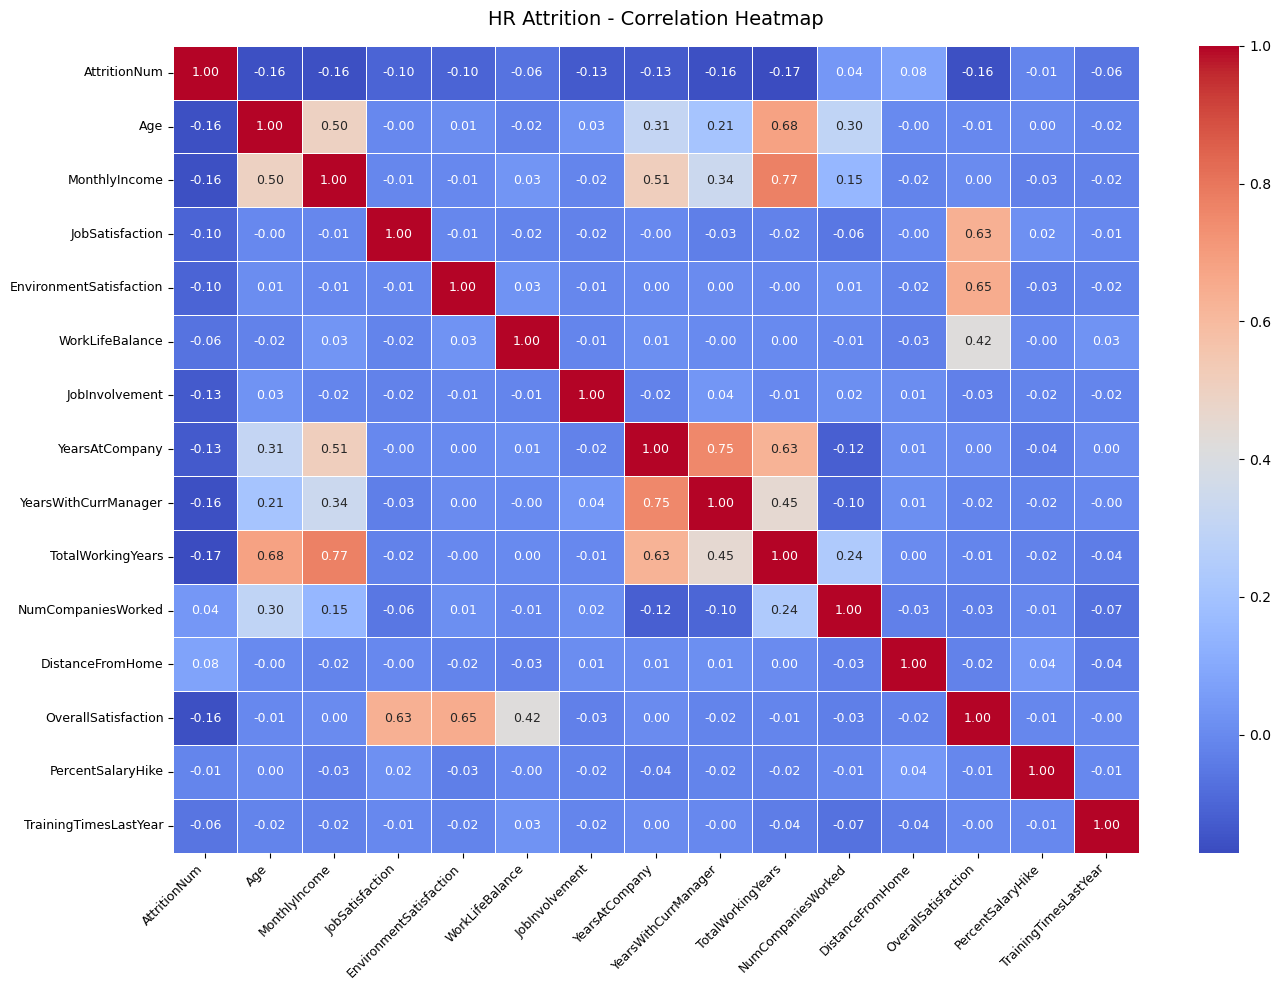

Heatmap saved in screenshots folder!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('screenshots', exist_ok=True)

# Recreate and save heatmap
cols_for_heatmap = [
    'AttritionNum', 'Age', 'MonthlyIncome', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
    'YearsAtCompany', 'YearsWithCurrManager', 'TotalWorkingYears',
    'NumCompaniesWorked', 'DistanceFromHome', 'OverallSatisfaction',
    'PercentSalaryHike', 'TrainingTimesLastYear'
]

plt.figure(figsize=(14,10))
sns.heatmap(
    df[cols_for_heatmap].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('HR Attrition - Correlation Heatmap', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('screenshots/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved in screenshots folder!")

In [1]:
readme_content = """# HR Attrition Analysis — End to End Project

## 🎯 Problem Statement
IBM wants to understand why employees leave and identify
which departments and roles are at highest attrition risk
so HR team can take preventive action.

## 🛠️ Tools Used
- Python (Pandas, Matplotlib, Seaborn) — Data cleaning & EDA
- PostgreSQL — Data storage & SQL analysis  
- Power BI — Interactive dashboard

## 📊 Dataset
- Source: IBM HR Analytics Dataset (Kaggle)
- Size: 1470 employees, 35 columns
- Type: Employee demographics, satisfaction scores, attrition status

## 🔄 Project Workflow
Raw CSV → Python Cleaning → PostgreSQL → Power BI Dashboard

## 📁 Project Structure
HR_Attrition_Project/
├── data/
│   ├── WA_Fn-UseC_-HR-Employee-Attrition.csv
│   └── hr_data_cleaned.csv
├── notebooks/
│   └── hr_attrition_analysis.ipynb
├── sql/
│   └── analysis_queries.sql
├── screenshots/
│   ├── heatmap.png
│   └── dashboard.png
└── README.md

## 🐍 Python / Pandas — What I Did
- Loaded raw dataset (1470 rows, 35 columns)
- Cleaned column names using str.strip()
- Removed 10 duplicate Employee IDs
- Filled 57 missing values in YearsWithCurrManager with median
- Dropped 3 constant columns (EmployeeCount, Over18, StandardHours)
- Created AttritionNum column (Yes=1, No=0)
- Feature Engineering:
  - TenureGroup — bucketed YearsAtCompany into 4 groups
  - OverallSatisfaction — combined 3 satisfaction scores
  - HighRisk flag — employees with overtime + low satisfaction

## 🗄️ SQL / PostgreSQL — What I Did
- Created hr_attrition_db database
- Loaded cleaned data using SQLAlchemy (df.to_sql)
- Wrote 8 analytical queries covering:
  - Basic aggregations (COUNT, SUM, AVG, ROUND)
  - GROUP BY analysis for department, role, salary, tenure
  - CASE WHEN for risk categorization
  - WINDOW FUNCTION (RANK) for department ranking
  - CTE for benchmarking against company average

## 📈 Power BI — Dashboard Visuals
1. KPI Cards — Total Employees, Attrition Count,
               Attrition Rate, Avg Salary, Avg Tenure
2. Combo Chart — Attrition Count & Rate by Age Group
3. Bar Chart — Attrition by Job Role
4. Donut Chart — Attrition by Department
5. Donut Chart — Attrition by Gender
6. Donut Chart — Attrition by Education
7. Column Chart — Attrition by Salary Slab
8. Matrix — Overtime Impact by Department
9. Slicers — Department, Age Group, Salary Slab

## 💡 Key Business Insights
1. Overall attrition rate is 16.12% — 237 out of 1470 employees left
2. Sales department has highest attrition at 20.63%
3. Employees doing overtime have 30%+ attrition vs 10% without
4. Upto 5k salary slab has highest attrition — low pay = high exit
5. 26-35 age group has highest attrition count
6. Male employees leave more (63.29%) than female (36.71%)
7. Life Sciences education field has highest attrition (37.55%)
8. Sales Representatives have highest role-wise attrition (40 employees)

## 📸 Dashboard Screenshot
!HR Attrition Dashboard(screenshot) 


"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("README created successfully!")

README created successfully!
